<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/food_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Vision

## Check the GPU
Google Colab offer free GPU, however not all of them are compatible with `mixed precision training`

[Google Colab offers](https://developer.nvidia.com/cuda-gpus):

* K80(not compatible)
* P100(not compatible)
* Tesla T4(compatible)

In [ ]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-b3a17c94-8887-b71a-05fd-abf35d849c38)


## Use TensorFlow Dataset to download data

In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt


In [ ]:
# list the available dataset
dataset_list = tfds.list_builders()
print('food101' in dataset_list) # it's a very long list so just check if your dataset is exist

True


In [ ]:
# load the dataset
(train_data, test_data), ds_info = tfds.load(name='food101',
                                             split=['train', 'validation'],
                                             as_supervised= True, # data get return in key value per(Tuple)
                                             shuffle_files=True,
                                             with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.ASD0S5_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.ASD0S5_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


# Exploring the food1001 data from TensorFlow Datasets
To become one with our data we want to find:
* Class names
* The shape of our input data (image tensore)
* The data type of our input data
* What the labels look like(e.g. are they one-hot encoded or are they label encoded)
* Do the label mutch up with the class names?

In [ ]:
# Feature of food101 from TFDS
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [ ]:
# Get the class names
class_names = ds_info.features['label'].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [ ]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
# Take one sample of the train data
train_one_sample = train_data.take(1) # samples are in the form of (image_tensor, label)
# What does one sample of our training data looks like
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
# Output info about our training data
for image, label in train_one_sample:
  print(f"""
        Image shape: {image.shape}
        Image datatype: {image.dtype}
        Target classe from food100(tensor form): {label}
        Class name(str form):  {class_names[label.numpy()]}
  """)


        Image shape: (512, 512, 3)
        Image datatype: <dtype: 'uint8'>
        Target classe from food100(tensor form): 21
        Class name(str form):  chocolate_cake
  


In [ ]:
# What does our image data from TFDS looks like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 32,  14,   0],
        [ 31,  13,   0],
        [ 28,  12,   0],
        ...,
        [ 54,  34,  10],
        [ 53,  33,   9],
        [ 51,  31,   7]],

       [[ 28,  10,   0],
        [ 28,  10,   0],
        [ 27,  11,   0],
        ...,
        [ 56,  36,  12],
        [ 55,  35,  11],
        [ 54,  34,   9]],

       [[ 30,  12,   0],
        [ 31,  13,   0],
        [ 31,  15,   0],
        ...,
        [ 58,  38,  13],
        [ 58,  38,  13],
        [ 58,  38,  11]],

       ...,

       [[135,  80,   0],
        [136,  81,   1],
        [137,  82,   2],
        ...,
        [ 13,   6,   0],
        [ 13,   6,   0],
        [ 13,   6,   0]],

       [[137,  82,   2],
        [137,  82,   2],
        [137,  82,   2],
        ...,
        [ 13,   6,   0],
        [ 13,   6,   0],
        [ 13,   6,   0]],

       [[136,  81,   1],
        [135,  80,   0],
        [135,  80,   0],
        ...,
        [ 14,   7,   

In [ ]:
# What are the min and max values of our image tensor?
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image form Tensorflow Dataset

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

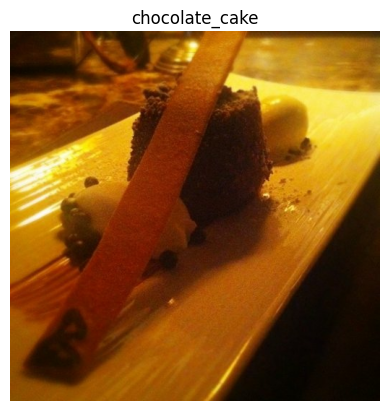

In [ ]:
# Plot an image
plt.imshow(image)
plt.title(class_names[label.numpy()])
plt.axis(False)

## Preprocess the data
Neural Network work best when the data is in certain way. e.g (Normalized, batched, and etc). However not all data including `Tensorflow Dataset` comes like this.

What we know about our data:
* It's in `unit8`
* Comprised of all diffirent size tensors (diffirent size of images)
* It's not scaled, the pixel values are between 0 and 255
What a model like:
* Data in `float32` dtype(or for mixed percision `float16` and `float32`)
* For `batches`, Tensorflow likes all of the tensors within a batch to be of the same size
* `Scaled`(Values between 0 and 1) also called normalization tensors perform better

Since we're going to use `EfficientNetBX` pretrained model from keras application we don't need to rescale our data(these architecture have rescalling build-in)

And Since we are not using `image_dataset_from_directory` we need the following steps:
* Make sure all the training and testing dataset has the same `shape`
* Covert the dtype of image tensors from `uint8` to `float32`
* We need to `normalize` the dataset
* Make sure our data is `Shuffled` during the training process
* Create `batches`
